# JOSS 2026

Original QMCPy demo: [`QMCPy/demos/talk_paper_demos/JOSS2026/joss2026.ipynb`](../../../../QMCPy/demos/talk_paper_demos/JOSS2026/joss2026.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/talk_paper_demos/JOSS2026/joss2026.ipynb)

Parity note: this archival Julia companion preserves the cited source and figure-defining examples, while allowing presentation-focused divergence needed for the checked-in JOSS notebook.


## Setup

In [1]:
using QMC
import Distributions
using Printf
using Statistics
import Logging

@isdefined(HAVE_PLOTS) || (const HAVE_PLOTS = Base.find_package("Plots") !== nothing)
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end


[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a](cache misses: wrong dep version loaded (3))


[ Info: Waiting for another process (pid: 174) to finish precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a]. Pidfile: /Users/terrya/.julia/compiled/v1.12/IJuliaExt/aTeZs_QPgIv.ji.pidfile



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## Listings

**Point Set Generation.**

A `DigitalNetB2` with `replications=R` produces an $R \times n \times d$ array — one independent randomization per replication.


In [2]:
dnb2_single = DigitalNetB2(2; randomize="LMS_DS")
x_single = gen_samples(dnb2_single, 2^7)
@printf("Single randomization:  shape = (%d, %d)\n", size(x_single)...)

dnb2_rep = DigitalNetB2(2; replications=5, randomize="LMS_DS")
x_rep = gen_samples(dnb2_rep, 2^7)
@printf("Five  randomizations:  shape = (%d, %d, %d)\n", size(x_rep)...)

@assert size(x_single) == (2^7, 2)
@assert all(0 .<= x_single .< 1)


Single randomization:  shape = (128, 2)
Five  randomizations:  shape = (5, 128, 2)


**Asian Option Pricing.**

A geometric Asian call option on a GBM path with 12 monthly monitoring dates. `CubQMCNetG` uses the Walsh-coefficient decay bound (the same algorithm as QMCPy's `CubQMCNetG`).


In [3]:
dd = DigitalNetB2(12; seed=7, randomize="LMS_DS", graycode=false)
tm = BrownianMotion(dd)
asian_option = FinancialOption(tm;
    option_type    = :asian,
    mean_type      = :geometric,
    volatility     = 0.5,
    start_price    = 30.0,
    strike_price   = 35.0,
    interest_rate  = 0.01,
)
sc = CubQMCNetG(asian_option; abs_tol=1e-3, rel_tol=0.0, n_init=2^8)
result = integrate(sc)
@printf("Asian option price ≈ %.4f\n", result.solution)
println(result)


Asian option price ≈ 1.7666
QMCResult(solution=1.766573e+00

, n_total=65536, error_bound=4.36e-04)


**Borehole Function.**

The [borehole function](https://www.sfu.ca/~ssurjano/borehole.html) models water flow through a borehole. The eight input parameters follow independent marginal distributions. `DistributionsWrapper` is the Julia equivalent of QMCPy's `SciPyWrapper`. `CubQMCBayesLatticeG` uses a Bayesian lattice rule with the Baker (tent) periodization transform.


In [4]:
function borehole(x)
    rw = x[:, 1]; r  = x[:, 2]; Tu = x[:, 3]; Hu = x[:, 4]
    Tl = x[:, 5]; Hl = x[:, 6]; L  = x[:, 7]; Kw = x[:, 8]
    log_r_rw = @. log(r / rw)
    numer = @. 2π * Tu * (Hu - Hl) / log_r_rw
    denom = @. 1 + 2L * Tu / (log_r_rw * rw^2 * Kw) + Tu / Tl
    return numer ./ denom
end

borehole_marginals = Distributions.UnivariateDistribution[
    Distributions.Normal(0.10, 0.0161812),
    Distributions.LogNormal(7.71, 1.0056),
    Distributions.Uniform(63070.0, 115600.0),
    Distributions.Uniform(990.0, 1110.0),
    Distributions.Uniform(63.1, 116.0),
    Distributions.Uniform(700.0, 820.0),
    Distributions.Uniform(1120.0, 1680.0),
    Distributions.Uniform(9855.0, 12045.0),
]

dd_bh = Lattice(8; seed=11)
tm_bh = DistributionsWrapper(dd_bh; marginals=borehole_marginals)
f_bh  = CustomFun(tm_bh, borehole)

sc_bh = CubQMCBayesLatticeG(f_bh; abs_tol=1e-3, rel_tol=1e-5, ptransform=:BAKER)
result_bh = integrate(sc_bh)
@printf("Borehole mean flow ≈ %.4f\n", result_bh.solution)
println(result_bh)


Borehole mean flow ≈ 73.7359
QMCResult(solution=7.373592e+01

, n_total=1024, error_bound=2.80e-06)


## Points

Scatter plots comparing IID uniform samples with three low-discrepancy sequences in 2D, showing how LD sequences fill the unit square more evenly than IID samples.


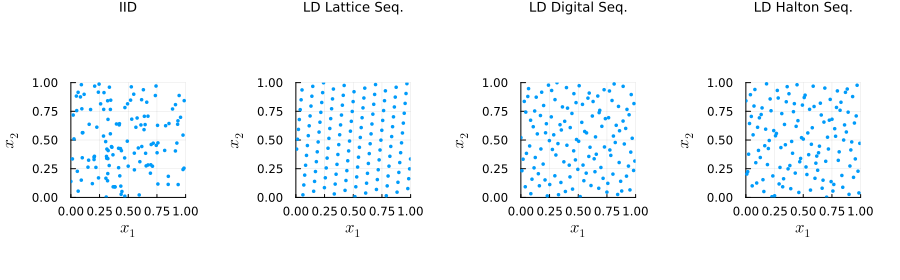

In [5]:
n_plot = 2^7
point_data = [
    ("IID",              IIDStdUniform(2; seed=7)),
    ("LD Lattice Seq.",  Lattice(2; seed=7)),
    ("LD Digital Seq.",  DigitalNetB2(2; seed=7, randomize="NUS")),
    ("LD Halton Seq.",   Halton(2; seed=7, randomize=true)),
]

if HAVE_PLOTS
    plots_list = []
    for (name, dd) in point_data
        local x = gen_samples(dd, n_plot)
        local p = scatter(x[:, 1], x[:, 2];
            title=name, xlabel="\$x_1\$", ylabel="\$x_2\$",
            xlims=(0,1), ylims=(0,1), aspect_ratio=:equal,
            xticks=[0, 0.25, 0.5, 0.75, 1], yticks=[0, 0.25, 0.5, 0.75, 1],
            markersize=2, markerstrokewidth=0, label=nothing, size=(250,280))
        push!(plots_list, p)
    end
    display(plot(plots_list...; layout=(1, 4), size=(900, 280)))
else
    for (name, dd) in point_data
        local x = gen_samples(dd, n_plot)
        @printf("  %-20s  mean=(%.4f, %.4f)\n", name, mean(x[:, 1]), mean(x[:, 2]))
    end
end


## Convergence

### Convergence Visualization

We compare three algorithms on the geometric Asian option problem across a range of tolerances. For each tolerance we run multiple independent trials and report median samples required. **The trial count is reduced from 100 to 20 to keep the notebook lightweight.**

IID MC uses `CubMCCLT` (CLT-based two-stage estimator), which becomes prohibitively slow for tight tolerances; it is only run for $arepsilon \geq 10^{-2}$.


In [6]:
d_conv  = 12
n_init  = 2^8
n_eps   = 10
n_trials = 20  # reduced from 100 for CI

eps_vec = 10 .^ range(log10(5e-1), log10(1e-4), length=n_eps)

function make_asian(dd)
    tm = BrownianMotion(dd)
    return FinancialOption(tm;
        option_type=:asian, mean_type=:geometric,
        volatility=0.5, start_price=30.0, strike_price=35.0, interest_rate=0.01)
end

n_totals = Dict{String, Matrix{Float64}}(
    k => fill(NaN, n_eps, n_trials)
    for k in ["IID MC", "QMC Lattice Seq.", "QMC Digital Seq."])

for (j, ε) in enumerate(eps_vec)
    for t in 1:n_trials
        # IID MC — only for large tolerances; NullLogger suppresses the CLT pilot-variance
        # overshoot warning that fires when the main-stage σ slightly exceeds the pilot estimate
        if ε >= 1e-2
            local sc = CubMCCLT(make_asian(IIDStdUniform(d_conv)); abs_tol=ε, rel_tol=0.0, n_init=n_init)
            local r = Logging.with_logger(Logging.NullLogger()) do
                integrate(sc)
            end
            n_totals["IID MC"][j, t] = r.data[:n_total]
        end

        try
            sc_lat = CubQMCLatticeG(make_asian(Lattice(d_conv)); abs_tol=ε, rel_tol=0.0, n_init=n_init)
            r_lat  = integrate(sc_lat)
            n_totals["QMC Lattice Seq."][j, t] = r_lat.data[:n_total]
        catch err
            if err isa ArgumentError && occursin("Lattice supports at most", sprint(showerror, err))
                t == 1 && @printf("Skipping lattice runs at ε = %.2e: sample cap reached\n", ε)
                n_totals["QMC Lattice Seq."][j, t:end] .= NaN
                break
            end
            rethrow()
        end

        dd_dig = DigitalNetB2(d_conv; randomize="LMS_DS", graycode=false)
        sc_dig = CubQMCNetG(make_asian(dd_dig); abs_tol=ε, rel_tol=0.0, n_init=n_init)
        r_dig  = integrate(sc_dig)
        n_totals["QMC Digital Seq."][j, t] = r_dig.data[:n_total]
    end
end

# Report median samples at each tolerance
println("Tolerance      IID MC (med)    Lattice (med)   Digital (med)")
println("-"^60)
for (j, ε) in enumerate(eps_vec)
    iid_med = isnan(n_totals["IID MC"][j, 1]) ? "      —     " :
              @sprintf("%12.0f", median(filter(!isnan, n_totals["IID MC"][j, :])))
    lat_vals = filter(!isnan, n_totals["QMC Lattice Seq."][j, :])
    lat_med = isempty(lat_vals) ? "      —     " : @sprintf("%12.0f", median(lat_vals))
    dig_med = @sprintf("%12.0f", median(n_totals["QMC Digital Seq."][j, :]))
    @printf("  %.2e    %s    %s    %s\n", ε, iid_med, lat_med, dig_med)
end

Skipping lattice runs at ε = 1.00e-04: sample cap reached
Tolerance      IID MC (med)    Lattice (med)   Digital (med)


------------------------------------------------------------
  5.00e-01            1226             256             256


  1.94e-01            5894             256             256
  7.53e-02           37534             512             512
  2.92e-02          242954            2048            1024
  1.13e-02         1908057            4096            4096
  4.41e-03          —                16384            8192
  1.71e-03          —                65536           16384
  6.64e-04          —               131072           65536
  2.58e-04          —               524288          131072
  1.00e-04          —               —                  NaN


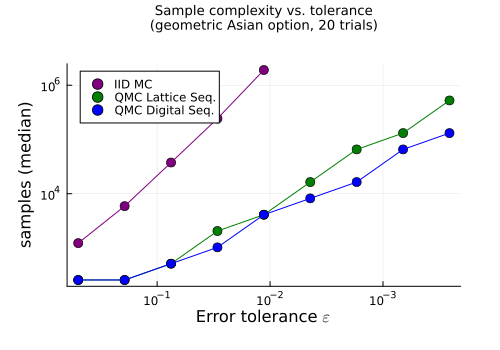

In [7]:
if HAVE_PLOTS
    colors = [:purple, :green, :blue]
    names  = ["IID MC", "QMC Lattice Seq.", "QMC Digital Seq."]
    p = plot(; xlabel="Error tolerance \$\\varepsilon\$", ylabel="samples (median)",
               xscale=:log10, yscale=:log10, xflip=true,
               title="Sample complexity vs. tolerance\n(geometric Asian option, 20 trials)",
               size=(500, 350), legend=:topleft)
    for (name, col) in zip(names, colors)
        valid = [j for j in 1:n_eps if !isnan(n_totals[name][j, 1])]
        isempty(valid) && continue
        med_n = [median(n_totals[name][j, :]) for j in valid]
        scatter!(p, eps_vec[valid], med_n; color=col, label=name, markersize=5)
        plot!(p, eps_vec[valid], med_n; color=col, label=nothing, linewidth=1)
    end
    display(p)
end
